In [1]:
!pip install mpi4py


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mpi4py: filename=mpi4py-3.1.5-cp310-cp310-linux_x86_64.whl size=2746494 sha256=0e06544f734bde4ac04edb841379a80d2c358cbca4c2fe57aa5c6e1a21dcc9c3
  Stored in directory: /root/.cache/pip/wheels/18/2b/7f/c852523089e9182b45fca50ff56f49a51eeb6284fd25a66713
Successfully built mpi4py


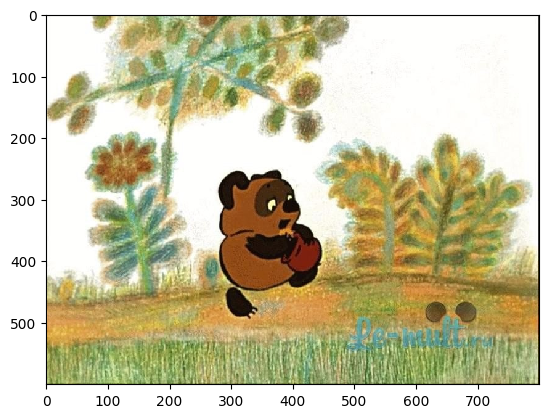

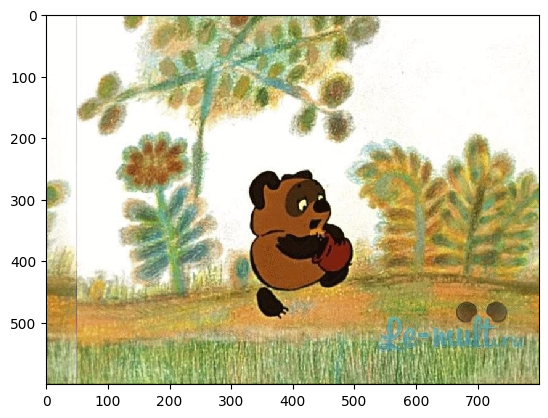

In [134]:
import numpy as np
# from mpi4py import MPI
# import time
import matplotlib.pylab as plt

im = np.array(plt.imread("vinni3.jpg"))
plt.figure()
plt.imshow(im, interpolation="none")

im2 = np.asarray(im)
im3 = im.copy()
n, m, k = im2.shape

# s = 100
# im2[:, s:, :] = im[:, :m-s, :]
# im2[:, :s, :] = im3[:, m-s:, :]


for i in range(50):
    im2[:, 1:, :] = im2[:, :m-1, :]
    im2[:, 0, :] = im2[:, m-1, :]

plt.figure()
plt.imshow(im2[:, :, :], interpolation="none")

In [156]:
%%writefile shift.py
import numpy as np
from mpi4py import MPI
import matplotlib.pylab as plt

def shift(image, buf):

    im2 = np.empty(image.shape, dtype = int)
    n, m, k = image.shape

    im2[:, 1:, :] = image[:, :m-1, :]
    im2[:, 0, :] = buf

    return im2

comm = MPI.COMM_WORLD

rank = comm.Get_rank()
size = comm.Get_size()

im = np.array(plt.imread("vinni3.jpg"))

n, m, k = im.shape

rank_m = m // size

if rank == size - 1:
    start, end = rank * rank_m, m

else:
    start, end = rank * rank_m, (rank + 1) * rank_m

im_rank = im[:, start:end, :].astype(int)

rank_size = end - start


for iter in range(50):

    buf_array = np.empty((n,k), dtype = int)
    send_array = im_rank[:, rank_size - 1, :].astype(int)

    if rank == 0:
        comm.Send(send_array, dest = rank + 1)

    if rank != size - 1 and rank != 0:
        comm.Recv(buf_array, source = rank - 1)
        comm.Send(send_array, dest = rank + 1)
        im_rank = shift(im_rank, buf_array)

    if rank == size - 1:
        comm.Recv(buf_array, source = size - 2)
        comm.Send(send_array, dest = 0)
        im_rank = shift(im_rank, buf_array)


    if rank == 0:
        comm.Recv(buf_array, source = size - 1)
        im_rank = shift(im_rank, buf_array)

    new_im = None

    if rank == 0:
        new_im = np.empty([size, n, rank_size, k], dtype = int)

    comm.Gather(im_rank, new_im, root=0)

    if rank == 0:

        image = new_im[0].copy()

        for i in range(1,size):
            image = np.append(image, new_im[i], axis = 1)

            plt.figure()
        plt.imshow(image, interpolation="none")
        plt.savefig(f'pic_{i}.png')

Overwriting shift.py


In [157]:
!mpirun -n 10 --allow-run-as-root --oversubscribe python shift.py

/content/shift.py:74: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


In [155]:
from PIL import Image

# Список для хранения кадров.
frames = []

for frame_number in range(50):
    # Открываем изображение каждого кадра.
    frame = Image.open(f'pic_{frame_number}.png')
    # Добавляем кадр в список с кадрами.
    frames.append(frame)

# Берем первый кадр и в него добавляем оставшееся кадры.
frames[0].save(
    'vinni.gif',
    save_all=True,
    append_images=frames[1:],  # Срез который игнорирует первый кадр.
    optimize=True,
    duration=100,
    loop=0
)